# Análise de Métricas e Validação do Agente Crítico

Este notebook executa o ciclo `Code Analyst` <-> `Critic Agent` e coleta métricas de qualidade, custo e alucinação.

In [1]:
import os
import sys
import pandas as pd
import time
import networkx as nx
import matplotlib.pyplot as plt

# Adicionar src ao path para importações funcionarem
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)

from src.code_analyst import analyze_codebase
from src.agents.critic import CriticAgent
from src.config import settings

# Configuração do Alvo
PROJECT_PATH = input("Qual projeto será analisado? ").strip() or os.getcwd()
PROJECT_NAME = os.path.basename(PROJECT_PATH)

print(f"Analisando projeto em: {PROJECT_PATH}")

Analisando projeto em: C:\Projetos Estudos\RAG\RAG-MPMG


## Definição do Loop de Feedback

In [2]:
# Classe Mock para quando não houver API Key
class MockCritic:
    def review(self, text, path):
         return {} 

def run_analysis_loop(max_retries=3):
    # Verificação de API Key para usar Mock se necessário
    use_mock = os.getenv("OPENROUTER_API_KEY") is None
    
    if use_mock:
        print("AVISO: API Key não encontrada. Usando Mocks para simulação.")
        critic = MockCritic()
    else:
        critic = CriticAgent()
        
    history = []
    
    current_feedback = None
    final_doc = None
    
    for i in range(max_retries + 1):
        print(f"\n--- Iteração {i} ---")
        start_time = time.time()
        
        # 1. Executar Analyst
        print("Executando Code Analyst...")
        
        if use_mock:
            # Mock do Analyst
            time.sleep(1)
            doc_text = "Docs v1 corrigido." if i > 0 else "Docs com erro."
            steps = 5 + i
            analyst_result = {"final_answer": doc_text, "steps": steps, "usage": {"total_tokens": 500}}
        else:
            try:
                analyst_result = analyze_codebase(PROJECT_PATH, PROJECT_NAME, feedback=current_feedback)
            except Exception as e:
                print(f"Erro no Analyst: {e}")
                break
        
        doc_text = analyst_result.get("final_answer", "")
        usage = analyst_result.get("usage", {})
        steps = analyst_result.get("steps", 0)
        
        # 2. Executar Critic
        print("Executando Critic Agent...")
        
        if use_mock:
             review_result = {"approved": i > 0, "score": 4 + i*5, "feedback": "Loop detectado." if i==0 else "Aprovado.", "hallucinations": []}
        else:
             review_result = critic.review(doc_text, PROJECT_PATH)
        
        end_time = time.time()
        duration = end_time - start_time
        
        # Registrar Métricas
        metrics = {
            "iteration": i,
            "duration_sec": round(duration, 2),
            "analyst_steps": steps,
            "quality_score": review_result.get("score", 0),
            "hallucinations_count": len(review_result.get("hallucinations", [])),
            "approved": review_result.get("approved", False),
            "feedback_length": len(review_result.get("feedback", "")),
            "total_tokens": usage.get("total_tokens", 0)
        }
        history.append(metrics)
        
        print(f"Resultado: Aprovado={review_result.get('approved', False)} | Score={review_result.get('score', 0)} | Alucinações={len(review_result.get('hallucinations', []))}")
        
        if review_result.get('approved', False):
            final_doc = doc_text
            print("Documentação Aprovada!")
            break
        else:
            current_feedback = review_result.get('feedback', 'Sem feedback')
            print(f"Feedback para melhoria: {current_feedback[:200]}...")
    
    return history, final_doc


## Execução e Coleta de Dados

In [3]:
# Executar o loop (pode levar alguns minutos)
metrics_history, final_documentation = run_analysis_loop(max_retries=2)

2026-02-20 10:57:15,663 | INFO     | Passo: Inicialização        | Tokens: 0      | CriticAgent Hierárquico (PraisonAI) inicializado.


[10:57:15] critic.py:65 INFO CriticAgent Hierárquico (PraisonAI) inicializado.



--- Iteração 0 ---
Executando Code Analyst...
2026-02-20 10:57:16,251 | INFO     | Passo: Inicialização        | Tokens: 0      | Iniciando análise de 'RAG-MPMG'. Arquivos: 603. Estratégia: RLM (Recursivo)


[10:57:16] code_analyst.py:21 INFO Iniciando análise de 'RAG-MPMG'. Arquivos: 603. Estratégia: RLM (Recursivo)


2026-02-20 10:57:16,263 | INFO     | Passo: Inicialização        | Tokens: 0      | Análise Agêntica (Graph) iniciada para: C:\Projetos Estudos\RAG\RAG-MPMG


...

2026-02-20 10:59:36,855 | INFO     | Passo: Inicialização        | Tokens: 0      | Documentação dividida em 1 seções para análise.


[10:59:36] critic.py:78 INFO Documentação dividida em 1 seções para análise.


2026-02-20 10:59:36,857 | ERROR    | Passo: Inicialização        | Tokens: 0      | Erro na execução hierárquica: asyncio.run() cannot be called from a running event loop


[10:59:36] critic.py:198 ERROR Erro na execução hierárquica: asyncio.run() cannot be called from a running event loop


Resultado: Aprovado=False | Score=0 | Alucinações=0
Feedback para melhoria: Exception na pipeline: asyncio.run() cannot be called from a running event loop...


## Resultados e Métricas

,iteration,duration_sec,analyst_steps,quality_score,hallucinations_count,approved,feedback_length,total_tokens
0,0,58.28,9,0,0,False,79,0
1,1,43.14,9,0,0,False,79,0
2,2,39.77,6,0,0,False,79,0


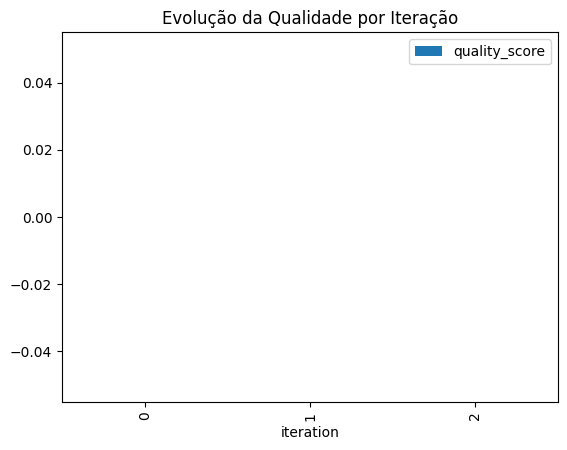

In [4]:
df = pd.DataFrame(metrics_history)
display(df)

# Exemplo de visualização simples
if not df.empty:
    try:
        df.plot(x='iteration', y='quality_score', kind='bar', title='Evolução da Qualidade por Iteração')
    except ImportError:
        print("Matplotlib não instalado, pulando gráfico.")

Documentação Final:
A documentação não foi aprovada pelo Crítico após as tentativas.

Loops detectados! Adicionando arco de refinamento no gráfico.


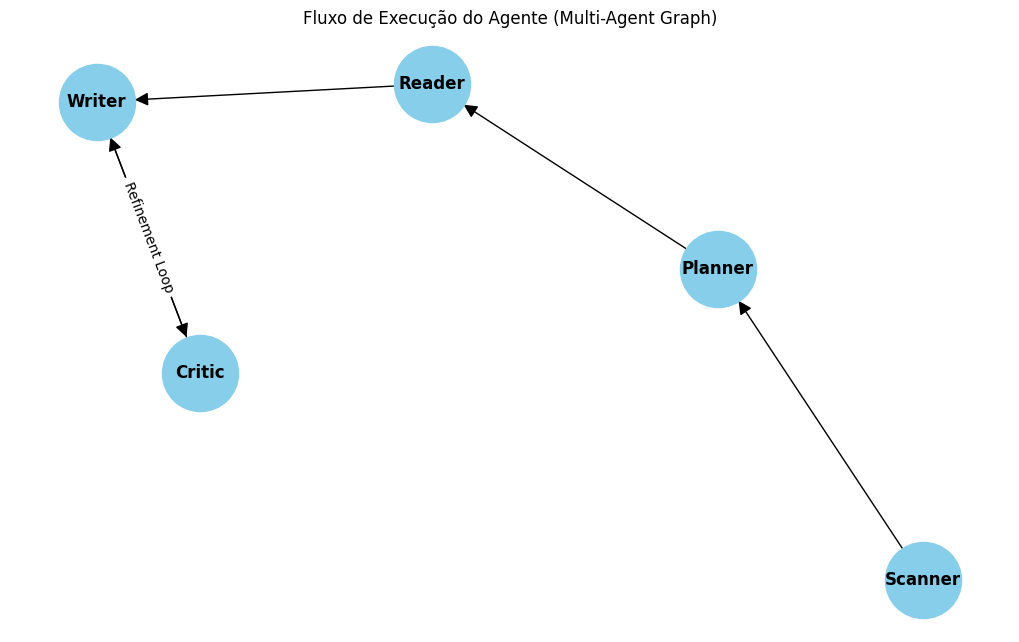

In [5]:
print("Documentação Final:")
if final_documentation:
    print(final_documentation[:1000] + "...")
else:
    print("A documentação não foi aprovada pelo Crítico após as tentativas.")

# --- Geração do Gráfico de Fluxo de Execução ---
G = nx.DiGraph()
nodes = ["Scanner", "Planner", "Reader", "Writer", "Critic"]
G.add_nodes_from(nodes)

edges = [
    ("Scanner", "Planner"),
    ("Planner", "Reader"),
    ("Reader", "Writer"),
    ("Writer", "Critic")
]
G.add_edges_from(edges)

# Se houve repetição no loop, adicionar o arco de retorno
if len(metrics_history) > 1:
    print("\nLoops detectados! Adicionando arco de refinamento no gráfico.")
    G.add_edge("Critic", "Writer", label="Refinement Loop")

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", 
        font_size=12, font_weight="bold", arrows=True, arrowsize=20)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Fluxo de Execução do Agente (Multi-Agent Graph)")
plt.show()